## Internal Datastructure: PYPOWER/MATPOWER Casefile (`ppc`)

Pandapower builds upon the well-known PYPOWER/MATPOWER data structure (`ppc`) to run load flow and short-circuit calculations. The `ppc` is essentially a Python dictionary that contains all system data in a structured form, with specific keys for buses, branches, generators, and other elements.

In short-circuit calculations, pandapower extends this concept by creating **sequence system representations** (positive, negative, zero sequence), so we can model asymmetrical faults in addition to symmetrical ones.

**Other resources for this exercise:**

- https://github.com/e2nIEE/pandapower/blob/master/tutorials/internal_datastructure.ipynb


The grid model will look like this:



### Why `ppc` is important
- It is the **internal data structure** used by the PYPOWER solver.
- It provides **bus and branch matrices** in a **flat numerical array format**, which makes computations efficient.
- In fault analysis, pandapower translates the user-defined network into the respective **positive, negative, and zero sequence systems**, represented as `ppci_1`, `ppci_2`, and `ppci_0`.



### Zero Sequence Case (`ppci_0`)
When running short-circuit calculations, pandapower constructs three casefiles:
- `ppci_1`: Positive sequence system
- `ppci_2`: Negative sequence system
- `ppci_0`: Zero sequence system

In [5]:
import pandapower as pp
from pandapower.shortcircuit.calc_sc import calc_sc

In [6]:
net = pp.from_json("2_five_bus_radial_grid_dyn_gen.json")
print(net)

This pandapower network includes the following parameter tables:
   - bus (5 elements)
   - load (2 elements)
   - sgen (2 elements)
   - gen (2 elements)
   - switch (8 elements)
   - ext_grid (1 element)
   - line (3 elements)
   - trafo (1 element)
 and the following results tables:
   - res_bus (5 elements)
   - res_line (3 elements)
   - res_trafo (1 element)
   - res_ext_grid (1 element)
   - res_load (2 elements)
   - res_sgen (2 elements)
   - res_gen (2 elements)
   - res_switch (8 elements)


### Setting network parameters

In this step, we adjust several key parameters of the network before running the short-circuit calculation:


In [16]:
net.sgen['k'] = 1.2
net.sgen['active_current'] = False
net.gen['current_source'] = False
net.sgen.in_service = False
net.gen.in_service = False
net.line["c0_nf_per_km"] = 0
net.line["c_nf_per_km"] = 0
net.gen.loc[net.gen.bus == 1, 'in_service'] = True


### Plotting the grid 

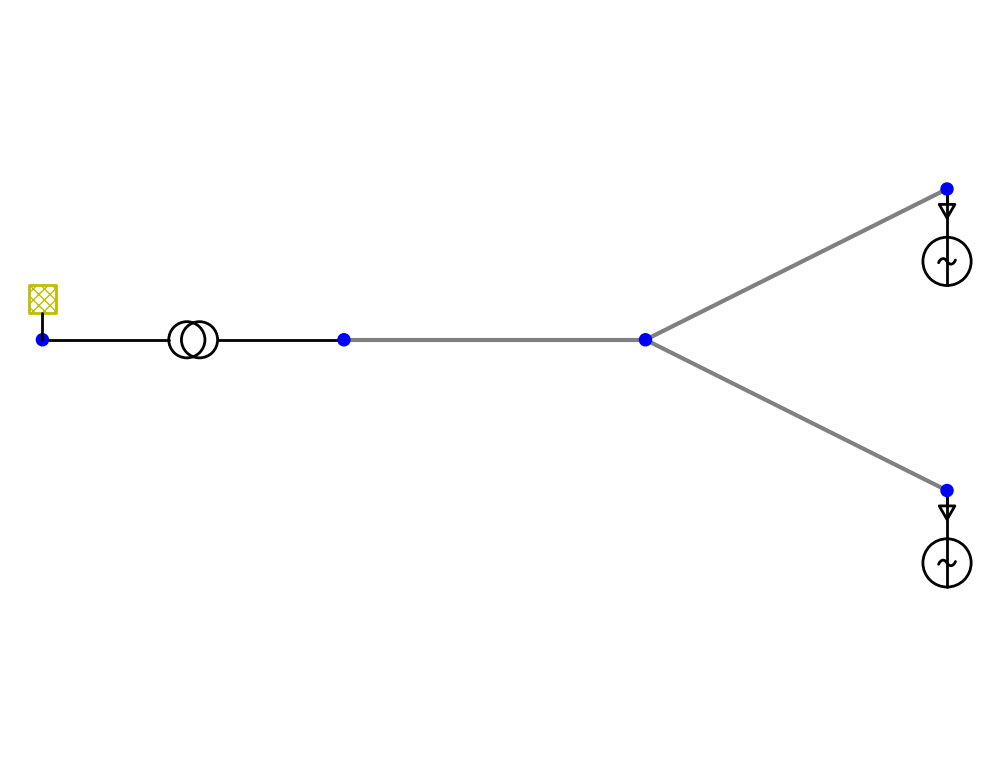

In [19]:
import pandapower.plotting as plot
from pandapower.plotting import simple_plot, create_generic_coordinates, set_line_geodata_from_bus_geodata
def plot(net):
    create_generic_coordinates(net, overwrite=True)
    set_line_geodata_from_bus_geodata(net, overwrite=True)

    simple_plot(
        net,
        line_width=3.,
        plot_loads=True, plot_gens=True, plot_sgens=False,
        load_size=1.5, gen_size=4., sgen_size=5., ext_grid_size=1.5, trafo_size=3
    )
plot(net)

For example, in a **three-phase symmetrical fault (LLL fault)**:
- The positive sequence network is the main contributor to the fault current.
- The negative and zero sequence networks are not directly coupled, but they are still constructed internally (important for asymmetrical faults like SLG, DLG).

Examining `ppci_0` gives insights into how pandapower represents the **zero sequence network**, which is especially critical for **single line-to-ground faults** where the zero sequence path dominates the fault current. If we dig deeper into structure

### Difference between `ppc` and `ppci`

The main difference between `ppc` and `ppci` in pandapower lies in their purpose and level of processing:

- **`ppc` (Pandapower/PYPOWER Casefile)**
  - Created directly from the pandapower `net`.
  - Contains all bus, branch, and generator data in MATPOWER-style arrays.
  - Keeps mappings to pandapower indices, making it closer to user input.
  - May include additional information not strictly needed for calculations.
  - Used as the "raw" casefile before optimization.


- **`ppci` (Internal Casefile)**
  - Derived from `ppc` just before running a power flow or short-circuit calculation.
  - Stripped of unnecessary information to improve performance.
  - Represents the solver-ready format actually passed to PYPOWER.
  - In short-circuit analysis, pandapower builds `ppci_0`, `ppci_1`, `ppci_2` for zero, positive, and negative sequence systems.


**In summary:**
- `ppc` is more descriptive and closer to the user-defined network.
- `ppci` is the optimized, minimal structure that the solver uses for computation.


### Structure of zero sequence `ppci_0`

```python
ppci_0
Out[2]:
{'baseMVA': 100.0,
 'version': 2,
 'bus': array([[ 0.00000000e+00,  3.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  9.04579277e+01, -9.04579264e+02,
          1.00000000e+00,  1.00000000e+00,  0.00000000e+00,
          1.10000000e+02,  1.00000000e+00,  2.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
                     nan,             nan,             nan,
                     nan,  1.00000000e+00,  1.10000000e+00,
                     nan,  0.00000000e+00,  0.00000000e+00,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan, -9.00000000e+01],
        [ 1.00000000e+00,  1.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00, -8.54830911e+02,
          1.00000000e+00,  1.00000000e+00,  0.00000000e+00,
          2.00000000e+01,  1.00000000e+00,  2.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.73472348e-18,  1.16982199e-01,             nan,
                     nan,  1.00000000e+00,  1.10000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
                     nan,             nan,             nan,
                     nan,  6.93889390e-18,  4.67928797e-01,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,  0.00000000e+00,
          0.00000000e+00,             nan, -9.00000000e+01],
        [ 2.00000000e+00,  1.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.00000000e+00,  1.00000000e+00,  0.00000000e+00,
          2.00000000e+01,  1.00000000e+00,  2.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
                     nan,             nan,             nan,
                     nan,  1.00000000e+00,  1.10000000e+00,
                     nan,  0.00000000e+00,  0.00000000e+00,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan, -9.00000000e+01],
        [ 3.00000000e+00,  1.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.00000000e+00,  1.00000000e+00,  0.00000000e+00,
          2.00000000e+01,  1.00000000e+00,  2.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
                     nan,             nan,             nan,
                     nan,  1.00000000e+00,  1.10000000e+00,
                     nan,  0.00000000e+00,  0.00000000e+00,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan, -9.00000000e+01],
        [ 4.00000000e+00,  1.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.00000000e+00,  1.00000000e+00,  0.00000000e+00,
          2.00000000e+01,  1.00000000e+00,  2.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
                     nan,             nan,             nan,
                     nan,  1.00000000e+00,  1.10000000e+00,
                     nan,  0.00000000e+00,  0.00000000e+00,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan, -9.00000000e+01]]),
 'bus_dc': array([], shape=(0, 11), dtype=float64),
 'branch': array([[ 1.00000000e+00+0.j,  2.00000000e+00+0.j,  9.23750028e-01+0.j,
          3.67500000e-01+0.j,  0.00000000e+00+0.j,  2.50000000e+02+0.j,
          2.50000000e+02+0.j,  2.50000000e+02+0.j,  1.00000000e+00+0.j,
          0.00000000e+00+0.j,  1.00000000e+00+0.j, -3.60000000e+02+0.j,
          3.60000000e+02+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,             nan+0.j,             nan+0.j,
                     nan+0.j,             nan+0.j,             nan+0.j,
                     nan+0.j,             nan+0.j,             nan+0.j,
                     nan+0.j,             nan+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j],
        [ 3.00000000e+00+0.j,  2.00000000e+00+0.j,  9.23750028e-01+0.j,
          3.67500000e-01+0.j,  0.00000000e+00+0.j,  2.50000000e+02+0.j,
          2.50000000e+02+0.j,  2.50000000e+02+0.j,  1.00000000e+00+0.j,
          0.00000000e+00+0.j,  1.00000000e+00+0.j, -3.60000000e+02+0.j,
          3.60000000e+02+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,             nan+0.j,             nan+0.j,
                     nan+0.j,             nan+0.j,             nan+0.j,
                     nan+0.j,             nan+0.j,             nan+0.j,
                     nan+0.j,             nan+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j],
        [ 4.00000000e+00+0.j,  2.00000000e+00+0.j,  9.23750028e-01+0.j,
          3.67500000e-01+0.j,  0.00000000e+00+0.j,  2.50000000e+02+0.j,
          2.50000000e+02+0.j,  2.50000000e+02+0.j,  1.00000000e+00+0.j,
          0.00000000e+00+0.j,  1.00000000e+00+0.j, -3.60000000e+02+0.j,
          3.60000000e+02+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,             nan+0.j,             nan+0.j,
                     nan+0.j,             nan+0.j,             nan+0.j,
                     nan+0.j,             nan+0.j,             nan+0.j,
                     nan+0.j,             nan+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j],
        [ 0.00000000e+00+0.j,  1.00000000e+00+0.j,  1.00000000e+22+0.j,
          1.00000000e+22+0.j,  0.00000000e+00+0.j,  2.50000000e+02+0.j,
          2.50000000e+02+0.j,  2.50000000e+02+0.j,  1.00000000e+00+0.j,
          0.00000000e+00+0.j,  1.00000000e+00+0.j, -3.60000000e+02+0.j,
          3.60000000e+02+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,             nan+0.j,             nan+0.j,
                     nan+0.j,             nan+0.j,             nan+0.j,
                     nan+0.j,             nan+0.j,             nan+0.j,
                     nan+0.j,             nan+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j]]),
 'branch_dc': array([], shape=(0, 15), dtype=float64),
 'tcsc': array([], shape=(0, 17), dtype=float64),
 'svc': array([], shape=(0, 11), dtype=float64),
 'ssc': array([], shape=(0, 10), dtype=float64),
 'vsc': array([], shape=(0, 17), dtype=float64),
 'gen': array([[ 0.e+00,  0.e+00,  0.e+00,  0.e+00,  0.e+00,  1.e+00,  1.e+00,
          1.e+00,  1.e+09, -1.e+09,  0.e+00,  0.e+00,  0.e+00,  0.e+00,
          0.e+00,  0.e+00,  0.e+00,  0.e+00,  0.e+00,  0.e+00,  0.e+00,
          0.e+00,  0.e+00,  0.e+00,  0.e+00,  1.e+00]]),
 'internal': {'Ybus': <Compressed Sparse Row sparse matrix of dtype 'complex128'
  	with 11 stored elements and shape (5, 5)>,
  'Yf': <Compressed Sparse Row sparse matrix of dtype 'complex128'
  	with 8 stored elements and shape (4, 5)>,
  'Yt': <Compressed Sparse Row sparse matrix of dtype 'complex128'
  	with 8 stored elements and shape (4, 5)>,
  'branch_is': array([ True,  True,  True,  True]),
  'branch_dc_is': array([], dtype=bool),
  'gen_is': array([ True]),
  'DLF': array([], dtype=complex128),
  'buses_ord_bfs_nets': array([], dtype=float64),
  'ac_slack_buses': [np.int64(0)],
  'svc_is': array([], dtype=bool),
  'ssc_is': array([], dtype=bool),
  'vsc_is': array([], dtype=bool),
  'tcsc_is': array([], dtype=bool),
  'ref_gens': array([0]),
  'Zbus': array([[ 1.09454093e-02+0.10945409j,  0.00000000e+00+0.j        ,
           0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
           0.00000000e+00-0.j        ],
         [ 0.00000000e+00+0.j        ,  1.73472348e-18+0.1169822j ,
          -2.27682456e-17+0.1169822j , -2.38524478e-17+0.1169822j ,
          -2.77555756e-17+0.1169822j ],
         [ 0.00000000e+00+0.j        , -1.38777878e-17+0.1169822j ,
           9.23750028e-01+0.4844822j ,  9.23750028e-01+0.4844822j ,
           9.23750028e-01+0.4844822j ],
         [ 0.00000000e+00+0.j        , -6.93889390e-18+0.1169822j ,
           9.23750028e-01+0.4844822j ,  1.84750006e+00+0.8519822j ,
           9.23750028e-01+0.4844822j ],
         [ 0.00000000e+00+0.j        , -2.08166817e-17+0.1169822j ,
           9.23750028e-01+0.4844822j ,  9.23750028e-01+0.4844822j ,
           1.84750006e+00+0.8519822j ]]),
  'baseI': array([1.90525589, 0.34641016, 0.34641016, 0.34641016, 0.34641016]),
  'valid_V': True,
  'V_ikss': array([[0.+0.j],
         [0.+0.j],
         [0.+0.j],
         [0.+0.j],
         [0.+0.j]]),
  'baseV': array([110.,  20.,  20.,  20.,  20.])}}
```

### Understanding Bus Columns in `ppci_0`

When we examine `ppci_0["bus"]`, we see a large numerical array with many columns.
At first glance, these values are difficult to interpret because each position corresponds to a specific parameter.

The mapping of these indices is defined in the following files:
- `sce\pandapower\pypower\idx_bus_sc.py` (short-circuit related indices)
- `sce\pandapower\pypower\idx_bus.py` (standard MATPOWER bus indices)

To make this easier to follow, in this example we will **use the variable names instead of raw numerical indices**.
This way, each column can be directly linked to its physical meaning (e.g., bus voltage, load model parameters, or short-circuit equivalents).

```python
ppci_0["bus"][1,:] = np.array([[
    # Standard bus parameters
    BUS_I, BUS_TYPE, PD, QD, GS, BS, BUS_AREA, VM, VA, BASE_KV, ZONE, VMAX, VMIN,

    # Load model parameters
    CID_P, CZD_P, SL_FAC, CID_Q, CZD_Q,

    # Short-circuit equivalents
    R_EQUIV, X_EQUIV, KAPPA, M, C_MIN, C_MAX, IKSSV, IKSSC, IKCV, IP, IB, ITH, IK,

    # Short-circuit in Ohms and scaling factors
    R_EQUIV_OHM, X_EQUIV_OHM, K_G, K_SG, V_G, PS_TRAFO_IX, GS_P, BS_P, GS_GEN, BS_GEN, SKSS,

    # Short-circuit angles
    PHI_IKSSV_DEGREE, PHI_IKSSC_DEGREE, PHI_IKCV_DEGREE
]])
```
##### Example: `ppci_0["bus"]` with actual values from ppci_0 presented before

```python
ppci_0["bus"] = np.array([[
    # Standard bus parameters
    0.0, 3.0, 0.0, 0.0, 90.4579277, -904.579264, 1.0, 1.0, 0.0, 110.0, 1.0, 2.0, 0.0,

    # Load model parameters
    0.0, 0.0, 0.0, 0.0, 0.0,

    # Short-circuit equivalents
    0.0, 0.0, 0.0, nan, nan, nan, nan, 1.0, 1.1, nan, 0.0, 0.0, nan,

    #  Short-circuit in Ohms and scaling factors
    nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,

    # Short-circuit angles
    nan, nan, -90.0
]])


In [15]:
import pandas as pd
pd.read_csv("ppci_bus_table.txt", sep="\t", index_col="Index")


,Variable,Value,Description
Index,,,
0,BUS_I,1.000000e+00,Bus number
1,BUS_TYPE,1.000000e+00,Bus type
2,PD,0.000000e+00,Real power demand (MW)
3,QD,0.000000e+00,Reactive power demand (MVAr)
4,GS,0.000000e+00,Shunt conductance (MW at V = 1.0 p.u.)
5,BS,-8.548309e+02,Shunt susceptance (MVAr at V = 1.0 p.u.)
6,BUS_AREA,1.000000e+00,Area number (1–100)
7,VM,1.000000e+00,Voltage magnitude (p.u.)
8,VA,0.000000e+00,Voltage angle (degrees)


### Understanding Branch Columns in `ppci_0`

When we examine `ppci_0["branch"]`, we see a large numerical array with many columns.
At first glance, these values are difficult to interpret because each position corresponds to a specific parameter.

The mapping of these indices is defined in the following files:
- `sce\pandapower\pypower\idx_brch_sc.py` (short-circuit related indices)
- `sce\pandapower\pypower\idx_brch.py` (standard MATPOWER branch indices)

To make this easier to follow, in this example we will **use the variable names instead of raw numerical indices**.
This way, each column can be directly linked to its physical meaning (e.g., from-bus, to-bus, line impedance, transformer tap, or short-circuit equivalents).


```python
ppci_0["branch"] = np.array([
    [
        # regular
        F_BUS, T_BUS, BR_R, BR_X, BR_B, RATE_A, RATE_B, RATE_C, TAP, SHIFT, BR_STATUS, ANGMIN, ANGMAX,
        # PF/OPF
        PF, QF, PT, QT, MU_SF, MU_ST, MU_ANGMIN, MU_ANGMAX,
        # asymmetry
        BR_R_ASYM, BR_X_ASYM, BR_G, BR_G_ASYM, BR_B_ASYM,
        # SC currents
        IKSS_F, IKSS_T, ITH_F, ITH_T, IP_F, IP_T, IK_F, IK_T, IB_F, IB_T, K_T, K_ST,
        # SC powers & voltages
        PKSS_F, QKSS_F, PKSS_T, QKSS_T, VKSS_MAGN_F, VKSS_MAGN_T, VKSS_ANGLE_F, VKSS_ANGLE_T,
        # SC angles
        IKSS_ANGLE_F, IKSS_ANGLE_T
    ]
])
```
##### Example: `ppci_0["branch"]` with actual values from ppci_0 presented before
```python
ppci_0["branch"] = np.array([
    [
        #Regular branch parameters
        1.0, 2.0, 0.92375, 0.3675, 0.0, 250.0, 250.0, 250.0, 1.0, 0.0,
        1.0, -360.0, 360.0,

        #Power flow / OPF variables
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

        #Asymmetry parameters
        0.0, 0.0, 0.0, 0.0, 0.0,

        #Short-circuit currents
        0.0, 0.0, nan, nan, nan, nan, nan, nan, nan, nan, 0.0, 0.0,

        #SC powers and voltages
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

        #SC angles
        0.0, 0.0
    ]

In [11]:
pd.read_csv("ppci_branch_table.txt", sep="\t", index_col="Index")

,Variable,Value,Description
Index,,,
0,F_BUS,3.00000,From bus number
1,T_BUS,2.00000,To bus number
2,BR_R,0.92375,Resistance (p.u.)
3,BR_X,0.36750,Reactance (p.u.)
4,BR_B,0.00000,Line charging susceptance (p.u.)
5,RATE_A,250.00000,MVA rating A (long term)
6,RATE_B,250.00000,MVA rating B (short term)
7,RATE_C,250.00000,MVA rating C (emergency)
8,TAP,1.00000,Transformer turns ratio
